# 2023년 의료기관별 시군구별 진료비 분석

## 단계: 04. 모델링 및 예측 분석 (Modeling & Predictive Analysis)
- **목적**: 3단계 통계 검정 결과를 바탕으로 진료비에 영향을 미치는 요인을 수치화하고 미래 데이터를 예측/분류하는 모델을 구축한다.

## 1. 데이터 준비 및 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
import statsmodels.api as sm

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('C:\data\hira_sigungu_2023.csv',
                 encoding='cp949')
df['1인당_진료비_만원'] = (
    df['요양급여비용총액(선별포함)']
    / df['환자수'] / 10000).round(1)
df['1인당_내원일수'] = (
    df['입내원일수']
    / df['환자수']).round(2)

# 종속변수 log 변환
df['log_진료비'] = np.log1p(
    df['1인당_진료비_만원'])

X_raw = df['1인당_내원일수']
Y = df['log_진료비']

## 2. [Model 01] 단순 선형회귀 분석

### 2.1 산점도 및 선형성 확인

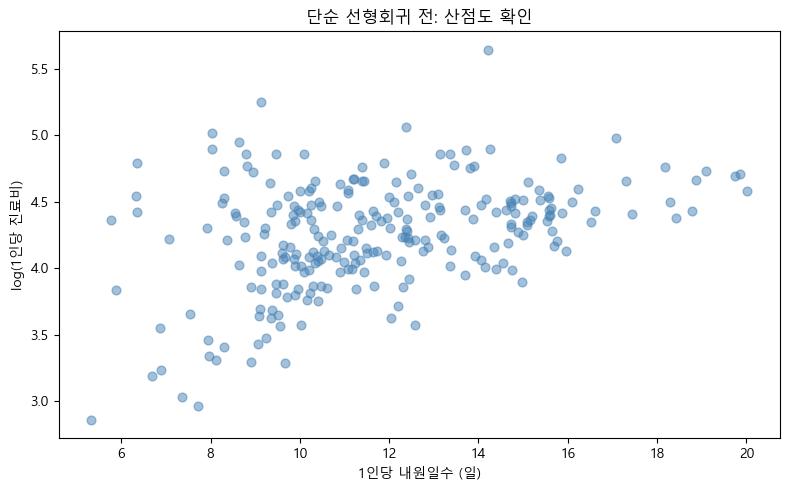

In [3]:
# 1. 산점도 확인
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_raw, Y, alpha=0.5,
           color='steelblue', s=40)
ax.set_xlabel('1인당 내원일수 (일)')
ax.set_ylabel('log(1인당 진료비)')
ax.set_title('단순 선형회귀 전: 산점도 확인')
plt.tight_layout()
plt.savefig('scatter_before.png', dpi=150)
plt.show()
#→ 데이터 분포와 이상치 확인

### 2.2 모델 적합 및 결과 해석

In [4]:
# 2. 모델 적합
# statsmodels: 상수항 수동 추가 필요
X = sm.add_constant(X_raw)
model = sm.OLS(Y, X).fit()

# 결과 출력
print(model.summary())
# → 계수, t값, p값, R², F통계량 모두 출력

                            OLS Regression Results                            
Dep. Variable:                log_진료비   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     44.39
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           1.71e-10
Time:                        17:59:02   Log-Likelihood:                -108.37
No. Observations:                 251   AIC:                             220.7
Df Residuals:                     249   BIC:                             227.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6100      0.099     36.296      0.0

In [5]:
# 3. 핵심 수치 추출
beta0 = model.params['const']
beta1 = model.params['1인당_내원일수']
r2 = model.rsquared
r2adj = model.rsquared_adj
fstat = model.fvalue
fpval = model.f_pvalue

print(f'\n절편 β₀ : {beta0:.4f}')
print(f'기울기 β₁ : {beta1:.4f}')
print(f'R²        : {r2:.4f}')
print(f'Adj. R²   : {r2adj:.4f}')
print(f'F 통계량  : {fstat:.4f}')
print(f'F p값     : {fpval:.6f}')

# β₁ 해석: log → 원래 값으로
pct_change = (np.exp(beta1) - 1) * 100
print(f'\n내원일수 1일 증가 →')
print(f' log 진료비 {beta1:.4f} 증가')
print(f' 원래 진료비 약 {pct_change:.1f}% 증가')


절편 β₀ : 3.6100
기울기 β₁ : 0.0547
R²        : 0.1513
Adj. R²   : 0.1479
F 통계량  : 44.3930
F p값     : 0.000000

내원일수 1일 증가 →
 log 진료비 0.0547 증가
 원래 진료비 약 5.6% 증가


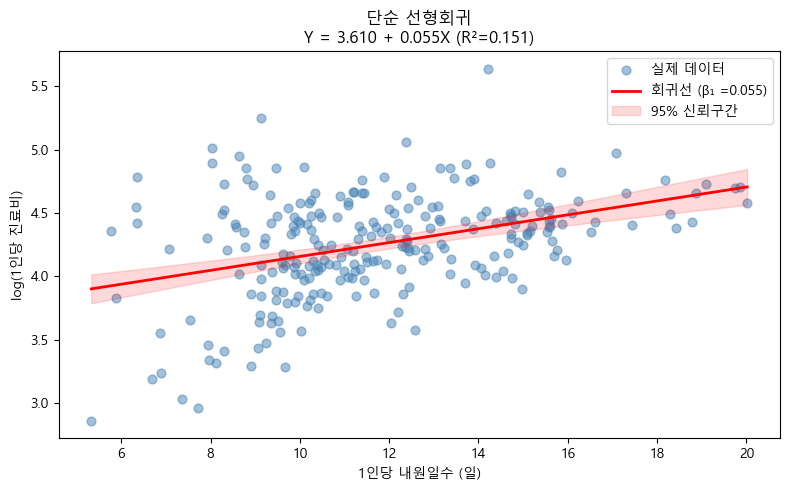

In [6]:
# 4. 회귀선 시각화
fig, ax = plt.subplots(figsize=(8, 5))

# 산점도
ax.scatter(X_raw, Y, alpha=0.5,
           color='steelblue', s=40,
           label='실제 데이터')

# 회귀선
x_fit = np.linspace(X_raw.min(),
                    X_raw.max(), 200)
y_fit = beta0 + beta1 * x_fit
ax.plot(x_fit, y_fit,
        color='red', lw=2,
        label=f'회귀선 (β₁ ={beta1:.3f})')

# 95% 신뢰구간
pred = model.get_prediction(
    sm.add_constant(
        pd.Series(x_fit,
                  name='1인당_내원일수')))
ci = pred.conf_int()
ax.fill_between(x_fit, ci[:,0], ci[:,1],
                alpha=0.15, color='red',
                label='95% 신뢰구간')

ax.set_xlabel('1인당 내원일수 (일)')
ax.set_ylabel('log(1인당 진료비)')
ax.set_title(
    f'단순 선형회귀\n'
    f'Y = {beta0:.3f} + {beta1:.3f}X '
f'(R²={r2:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('slr_result.png', dpi=150)
plt.show()

### 2.3 잔차 진단 (가정 검정)

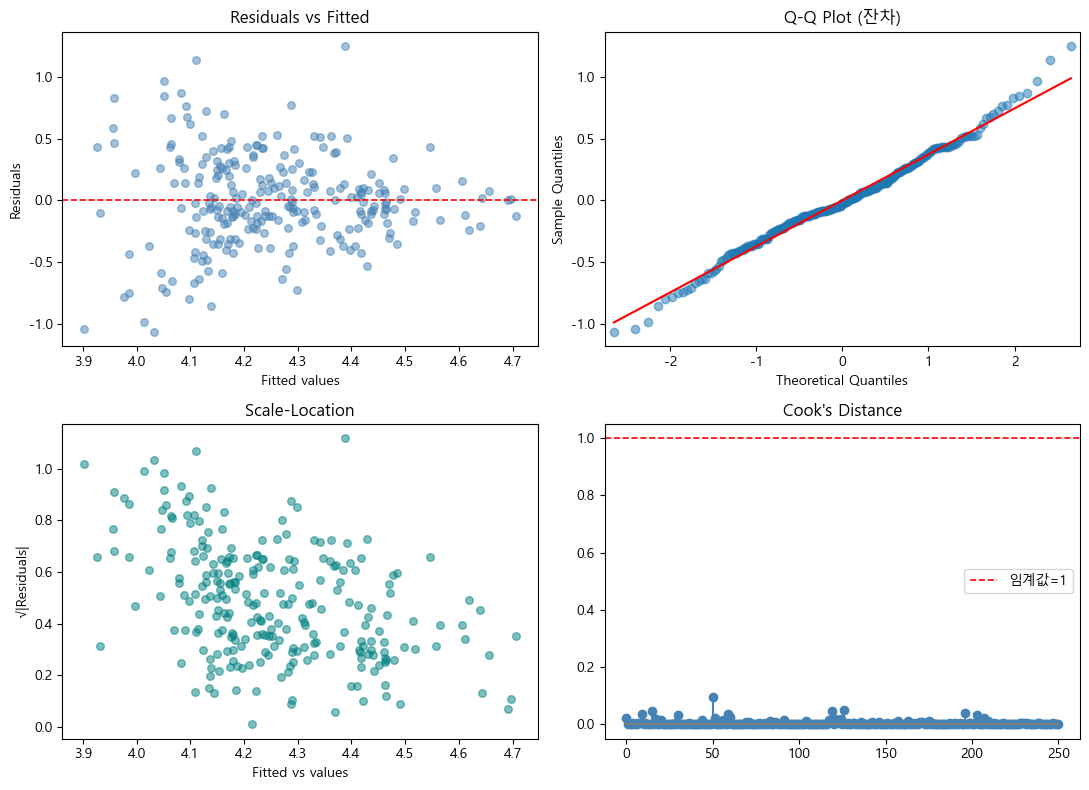

In [7]:
# 5. 잔차 진단 4종
fig, axes = plt.subplots(2, 2,
                         figsize=(11, 8))

# (1) Residual vs Fitted
fitted = model.fittedvalues
resid = model.resid
axes[0,0].scatter(fitted, resid,
                 alpha=0.5, s=30, color='steelblue')
axes[0,0].axhline(0, color='red',
                  ls='--', lw=1.2)
axes[0,0].set_xlabel('Fitted values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# (2) Q-Q Plot
sm.qqplot(resid, line='s', ax=axes[0,1],
          alpha=0.5)
axes[0,1].set_title('Q-Q Plot (잔차)')

# (3) Scale-Location
sqrt_resid = np.sqrt(np.abs(resid))
axes[1,0].scatter(fitted, sqrt_resid,
                  alpha=0.5, s=30, color='teal')
axes[1,0].set_xlabel('Fitted vs values')
axes[1,0].set_ylabel('√|Residuals|')
axes[1,0].set_title('Scale-Location')

# (4) Cook's Distance
influence = model.get_influence()
cooks = influence.cooks_distance[0]
axes[1,1].stem(range(len(cooks)),
               cooks, markerfmt='o',
               linefmt='steelblue',
               basefmt='gray')
axes[1,1].axhline(1, color='red',
                  ls='--', lw=1.2, label='임계값=1')
axes[1,1].set_title("Cook's Distance")
axes[1,1].legend()

plt.tight_layout()
plt.savefig('residual_diag.png', dpi=150)

In [8]:
# 화순군 제외 후 분석해보기
df_no_hwasun = df[df['시군구'] != '화순군']
X2 = sm.add_constant(df_no_hwasun['1인당_내원일수'])
Y2 = df_no_hwasun['log_진료비']
model2 = sm.OLS(Y2, X2).fit()
print(f'화순군 포함: R²={model.rsquared:.3f}, β₁={model.params.iloc[1]:.4f}')
print(f'화순군 제외: R²={model2.rsquared:.3f}, β₁={model2.params.iloc[1]:.4f}')

화순군 포함: R²=0.151, β₁=0.0547
화순군 제외: R²=0.150, β₁=0.0533


# 회귀분석 결과 요약 및 해석 (Model 01)

## 1. 핵심 회귀 계수 (Coefficients)

| 항목 | 구분 | 수치 | 해석 |
|:---:|:---:|:---:|:---|
| **절편** | $\beta_0$ | **3.610** | 내원일수가 0일 때의 예측 $\log$ 진료비 (약 36.97만원) |
| **기울기** | $\beta_1$ | **+0.0547** | 내원일수 1일 증가 시 진료비 약 **5.6% 증가** (exp(0.0547)-1 = 0.0562) |
| **결정계수** | $R^2$ | **0.151** | 내원일수가 진료비 변동의 **15.1%** 를 설명함 |

---

## 2. 세부 지표 읽는 법

| 항목 | 값 | 해석 |
|:---:|:---:|:---|
| **coef ($\beta_1$)** | 0.0547 | 내원일수 1일 증가 → $\log$ 진료비 0.0547 증가 → **실제 진료비 약 5.6% 증가** |
| **std err** | 0.008 | $\beta_1$ 추정의 불확실성. 작을수록 정밀한 추정임을 의미함 |
| **t 값** | 6.663 | $\beta_1 \div \text{std err}$. 절대값이 2보다 크므로 통계적으로 유의함 |
| **P>|t|** | 0.000 | $p < 0.05$ 이므로 $\beta_1$이 0이 아님이 **통계적으로 유의**함 |
| **$R^2$** | 0.151 | 모델의 설명력. 내원일수 하나로는 설명력이 낮아 다중 회귀 분석이 필요함 |
| **F-statistic** | 44.39 | 모델 전체의 유의성. Prob(F) < 0.05 이므로 모델 자체는 유의미함 |

> **$R^2=0.151$이 낮은 이유와 다음 단계**  
> 현재 모델은 내원일수 하나만 고려하고 있습니다. 환자수($\rho=0.501$)나 지역적 특성(더미 변수)을 추가하면 설명력이 크게 향상될 것입니다. 이것이 **Model 02(다중 선형회귀)**로 넘어가야 하는 핵심 이유입니다.

---

## 3. 잔차 진단 (Residual Diagnostics)
*회귀 분석의 가정을 충족하는지 4가지 차트로 확인합니다.*

1. **Residuals vs Fitted (선형성 & 등분산성)**
   - 잔차가 0 주변에 무작위로 퍼져 있어야 정상입니다.
   - 본 데이터는 높은 예측값에서 잔차가 커지는 경향이 있으며, 특정 이상치(화순군 등)에서 큰 잔차가 발생합니다.

2. **Normal Q-Q (잔차의 정규성)**
   - 점들이 대각선에 가까울수록 정규분포를 따릅니다.
   - 양 끝단의 이탈이 있으나, $\log$ 변환 전보다 훨씬 개선되었으며 중앙부는 양호합니다.

3. **Scale-Location (등분산성 집중 진단)**
   - 추세선이 수평을 유지해야 합니다.
   - 오른쪽으로 갈수록 선이 올라가는 것은 이상치(화순군 등)의 영향으로 분산이 증가하는 이분산성 신호입니다.

4. **Cook's Distance (영향력 이상치 탐지)**
   - 값이 1을 초과하면 모델을 크게 흔드는 이상치입니다.
   - 전남 화순군(280.6만원)과 같은 데이터가 회귀계수($\beta_1$)에 미치는 영향을 체크해야 합니다.

---

## 4. 모델 요약 및 결론

### 회귀 공식
$$\log(\text{1인당 진료비}) = 3.610 + 0.0547 \times (\text{1인당 내원일수})$$

### 결론 3줄 요약
1. **내원일수 1일 증가 시** 1인당 진료비는 **약 5.6% 증가**합니다. ($p < 0.001$로 유의미)
2. 현재 모델의 **설명력($R^2$)은 15.1%**로, 내원일수 외에 다른 변수의 영향이 큽니다.
3. 설명력을 높이기 위해 **환자수, 지역 더미 변수를 포함한 다중 회귀 모델** 도입이 필요합니다.

In [9]:
# 6. 잔차 수치 진단
from statsmodels.stats.diagnostic import (
het_breuschpagan,
linear_rainbow
)
from statsmodels.stats.stattools import (
durbin_watson
)

resid = model.resid
fitted = model.fittedvalues
X_with_const = model.model.exog

print("=" * 45)
print("잔차 수치 진단 결과")
print("=" * 45)

# (1) 잔차 정규성 - Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(resid)
print(f'\n1. 정규성 (Shapiro-Wilk)')
print(f' W통계량 : {sw_stat:.4f}')
print(f' p값 : {sw_p:.4f}')
if sw_p > 0.05:
    print(' → 정규성 충족 (p > 0.05)')
else:
    print(' → 정규성 기각 (p < 0.05)')

# (2) 등분산성 - Breusch-Pagan
bp_stat, bp_p, f_stat, f_p = het_breuschpagan(
    resid, X_with_const)
print(' \n2. 등분산성 (Breusch-Pagan)')
print(f' LM통계량 : {bp_stat:.4f}')
print(f' p값 : {bp_p:.4f}')
if bp_p > 0.05:
    print(' → 등분산성 충족 (p > 0.05)')
else:
    print(' → 이분산성 의심 (p < 0.05)')
    print(' 대응 : HC3 강건 표준오차 사용 고려')

# (3) 자기상관 - Durbin-Watson
dw_stat = durbin_watson(resid)
print('\n3. 자기상관 (Durbon-Watson)')
print(f' DW 통계량: {dw_stat:.4f}')
print(f' 기준값: 2.0(독립)')
if 1.5 <= dw_stat <= 2.5:
    print(' → 자기상관 없음')
elif dw_stat < 1.5:
    print(' → 양의 자기상관 의심')
else:
    print(' → 음의 자기상관 의심')

# (4) 선형성 - Rainbow Test
rb_stat, rb_p = linear_rainbow(model)
print(f'\n4. 선형성 (Rainbow Test)')
print(f' F통계량: {rb_stat:.4f}')
print(f' p값: {rb_p:.4f}')
if rb_p > 0.05:
    print('→ 선형 모델 형태 적절')
else:
    print(' → 비선형 관계 가능성')

# (5) 잔차 기술통계 요약
print('\n5. 잔차 기술통계')
print(f' 평균: {resid.mean():.6f} (≈0이어야 정상)')
print(f' 표준편차: {resid.std():.4f}')
print(f' 최솟값: {resid.min():.4f}')
print(f' 최댓값: {resid.max():.4f}')
print(f' 왜도: {stats.skew(resid):.4f}')
print(f' 첨도: {stats.kurtosis(resid):.4f}')

print("\n" + "=" * 45)

# (6) 이분산성 대응: 강건 표준오차
# Breusch-Pagan이 유의하면 아래 실행
model_robust = sm.OLS(Y, X).fit(
    cov_type='HC3') # HC3: 강건 표준오차

print('\n강건 표준오차(HC3) 적용 비교:')
print(f' β₁ (일반) : {model.params.iloc[1]:.4f}'
      f' ± {model.bse.iloc[1]:.4f}')
print(f' β₁ (강건) : {model_robust.params.iloc[1]:.4f}'
      f' ± {model_robust.bse.iloc[1]:.4f}')
print(f' p값 (일반) : {model.pvalues.iloc[1]:.4f}')
print(f' p값 (강건) : {model_robust.pvalues.iloc[1]:.4f}')

잔차 수치 진단 결과

1. 정규성 (Shapiro-Wilk)
 W통계량 : 0.9905
 p값 : 0.0997
 → 정규성 충족 (p > 0.05)
 
2. 등분산성 (Breusch-Pagan)
 LM통계량 : 34.0437
 p값 : 0.0000
 → 이분산성 의심 (p < 0.05)
 대응 : HC3 강건 표준오차 사용 고려

3. 자기상관 (Durbon-Watson)
 DW 통계량: 1.4257
 기준값: 2.0(독립)
 → 양의 자기상관 의심

4. 선형성 (Rainbow Test)
 F통계량: 1.2621
 p값: 0.0979
→ 선형 모델 형태 적절

5. 잔차 기술통계
 평균: -0.000000 (≈0이어야 정상)
 표준편차: 0.3734
 최솟값: -1.0669
 최댓값: 1.2519
 왜도: 0.1185
 첨도: 0.6653


강건 표준오차(HC3) 적용 비교:
 β₁ (일반) : 0.0547 ± 0.0082
 β₁ (강건) : 0.0547 ± 0.0091
 p값 (일반) : 0.0000
 p값 (강건) : 0.0000


## 3-2. 잔차 수치 진단 (통계 검정) — 실제 결과

| 검정 | 검정명 | 통계량 | p값 | 판정 |
|:---:|:---:|:---:|:---:|:---:|
| 정규성 | Shapiro-Wilk | W=0.9905 | 0.0997 | 충족 |
| 등분산성 | Breusch-Pagan | LM=34.04 | **0.0000** | **이분산성 유의** |
| 자기상관 | Durbin-Watson | DW=1.4257 | — | 횡단면 데이터 — 해당 없음 |
| 선형성 | Rainbow Test | F=1.2621 | 0.0979 | 충족 |

> **첨도 해석 주의:** scipy는 초과 첨도(excess kurtosis)를 반환합니다.  
> 출력값 0.6653 = 실제 첨도 3.665 (= 0.6653 + 3)로 정규분포 수준입니다.

> **Durbin-Watson 해석 주의:** DW=1.4257로 임계값(1.5) 미만이나,  
> 이 데이터는 횡단면(cross-sectional) 데이터이므로 시계열 자기상관 검정인  
> DW 검정이 적합하지 않습니다. 실질적 문제 없음.

### 이분산성 대응

Breusch-Pagan LM=34.04 (p<0.001)로 이분산성이 통계적으로 유의하게 확인됩니다.
HC3 강건 표준오차 적용 결과:

| 구분 | β₁ | std err | p값 |
|:---:|:---:|:---:|:---:|
| 일반 OLS | 0.0547 | 0.0082 | 0.0000 |
| HC3 강건 | 0.0547 | 0.0091 | 0.0000 |

> **결론:** 이분산성이 존재하나 HC3 적용 후 계수(β₁)와 유의성(p값) 동일.  
> 주요 결론("내원일수 증가 시 진료비 5.6% 증가, p<0.001")은 변하지 않음.

### 시각화 + 수치 종합 판정 (최종)

| 가정 | 시각적 판단 | 수치 검정 | 최종 판정 |
|:---:|:---:|:---:|:---:|
| 선형성 | 패턴 없음 | p=0.098 | **충족** |
| 독립성 | 횡단면 | — (DW 해당 없음) | **충족** |
| 등분산성 | 약한 의심 | p<0.001 | **위반 확인** → HC3 적용 |
| 잔차 정규성 | Q-Q 양호 | p=0.100 | **충족** |

## 3. [Model 02] 다중 선형회귀 분석

### 3.1 다중공선성(VIF) 및 표준화 계수 분석

In [10]:
# 사전준비
import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor
from statsmodels.stats.diagnostic import (
het_breuschpagan, linear_rainbow)
from scipy import stats
df = pd.read_csv('C:\data\hira_sigungu_2023.csv',
                 encoding='cp949')
df['1인당_진료비_만원'] = (
    df['요양급여비용총액(선별포함)']
    / df['환자수'] / 10000).round(1)
df['1인당_내원일수'] = (
    df['입내원일수']
    / df['환자수']).round(2)
df['log_진료비'] = np.log1p(
    df['1인당_진료비_만원'])
df['log_환자수'] = np.log1p(df['환자수'])
df['광역시'] = df['시도'].isin(
    ['서울','부산','대구','인천',
     '광주','대전','울산','세종']
).astype(int)
df['강원더미'] = (df['시도']=='강원').astype(int)

Y = df['log_진료비']

# 1. 변수 구성 & 모델 적합
# 독립변수 4개 설정

X_vars = ['1인당_내원일수', 'log_환자수', '광역시', '강원더미']
X = sm.add_constant(df[X_vars])

model2 = sm.OLS(Y, X).fit()
print(model2.summary())

# 2. 핵심 수치 추출
print('\n===== 핵심 수치 =====')
for var, coef, pval in zip(
    X_vars,
    model2.params[1:],
    model2.pvalues[1:]):
    pct = (np.exp(coef)-1)*100
    sig = '[유의]' if pval < 0.05 else '[미흡]'
    print(f'▶ {sig} {var}')
    print(f'   β = {coef:.4f}'
          f'   p = {pval:.4f}'
          f'   진료비 변화 ≈ {pct:.1f}%')
print(f'\nR² : {model2.rsquared:.4f}')
print(f'Adj R² : {model2.rsquared_adj:.4f}')
print(f'AIC : {model2.aic:.2f}')
print(f'BIC : {model2.bic:.2f}')

# 3. VIF 계산
print('\n ===== VIF (다중공선성) =====')
vif_data = pd.DataFrame()
vif_data['변수'] = X_vars

X_vif = sm.add_constant(df[X_vars])
vif_data['VIF'] = [
    variance_inflation_factor(
        X_vif.values, i+1)
    for i in range(len(X_vars))
]
vif_data['판정'] = vif_data['VIF'].apply(
    lambda v: '양호' if v < 5
    else ('주의' if v < 10
    else '심각'))
print(vif_data.to_string(index=False))

# 4. 표준화 계수
print('\n ===== 표준화 계수 (β*) =====')
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(df[X_vars])
X_sc = sm.add_constant(X_scaled)
model2_sc = sm.OLS(Y, X_sc).fit()

std_coefs = pd.DataFrame({
    '변수': X_vars,
    'β*': model2_sc.params[1:].round(4),
    'p값': model2_sc.pvalues[1:].round(4)
}).sort_values('β*', key=abs,
               ascending=False)
print(std_coefs.to_string(index=False))
print('→|β*| 클수록 Y에 더 큰 영향')

# 5. 잔차 수치 진단
resid2 = model2.resid
X_exog = model2.model.exog

sw_s, sw_p = stats.shapiro(resid2)
bp_s, bp_p, _, _ = het_breuschpagan(
    resid2, X_exog)
rb_s, rb_p = linear_rainbow(model2)

print(f'\n ===== 잔차 진단 =====')
print(f"Shapiro-Wilk p = {sw_p:.4f}"
      f"{'[정규성 만족]' if sw_p>0.05 else '[정규성 미흡]'}")
print(f" Breusch-Pagan p = {bp_p:.4f}"
      f"{'[등분산성 만족]' if bp_p>0.05 else '[이분산성 의심]'}")
print(f"Rainbow Test p = {rb_p:.4f}"
      f"{'[선형성 만족]' if rb_p>0.05 else '[비선형성 의심]'}")

# 6. 모델01 vs 02 비교
# (model은 앞서 정의한 단순회귀)
print('\n ===== 모델 01 vs 02 비교 =====')
print(f"{'항목':<12} {'단순회귀':>10}"
      f"{'다중회귀':>10}")
print("-"*34)
for label, v1, v2 in [
    ("R²", model.rsquared,
           model2.rsquared),
    ("Adj R²", model.rsquared_adj,
               model2.rsquared_adj),
    ("AIC", model.aic, model2.aic),
    ("BIC", model.bic, model2.bic),
]:
    print(f"{label:<12} {v1:>10.4f}"
          f"{v2:>10.4f}")

                            OLS Regression Results                            
Dep. Variable:                log_진료비   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     113.4
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           1.18e-54
Time:                        17:59:03   Log-Likelihood:                 2.2207
No. Observations:                 251   AIC:                             5.559
Df Residuals:                     246   BIC:                             23.19
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3375      0.209      1.619      0.1

### 3.2 잔차 수치 진단 및 강건성 검정 (HC3)
### 3.3 이상치 영향력 분석 (화순군 제외)

In [11]:
# HC3 강건 표준오차 모델
model2_hc3 = sm.OLS(Y, X).fit(cov_type='HC3')

print("===== HC3 강건 표준오차 적용 후 =====")
print(f"{'변수':<15} {'β':>8} {'일반 p':>8} {'HC3 p':>8} {'결론'}")
print("="*52)
for var in X_vars:
    b     = model2.params[var]
    p_ols = model2.pvalues[var]
    p_hc3 = model2_hc3.pvalues[var]
    changed = "변화" if (p_ols<0.05) != (p_hc3<0.05) else "동일"
    print(f"{var:<15} {b:>8.4f} {p_ols:>8.4f} {p_hc3:>8.4f} {changed}")

# 이상치 제외 재분석
df_no = df[df['시군구'] != '화순군'].copy()
Y_no = df_no['log_진료비']
X_no = sm.add_constant(df_no[X_vars])
m2_no = sm.OLS(Y_no, X_no).fit()

from scipy import stats as sc
sw_no = sc.shapiro(m2_no.resid)
print(f"\n ===== 화순군 제외 후 =====")
print(f"R²         : {m2_no.rsquared:.4f} (포함: {model2.rsquared:.4f})")
print(f"β_내원일수 : {m2_no.params['1인당_내원일수']:.4f} (포함: {model2.params['1인당_내원일수']:.4f})")
print(f"잔차 SW p  : {sw_no[1]:.4f} (포함 0.0000)")
print(f"→ 정규성 {'충족' if sw_no[1]>0.05 else '여전히 위반'}")

===== HC3 강건 표준오차 적용 후 =====
변수                     β     일반 p    HC3 p 결론
1인당_내원일수          0.0893   0.0000   0.0000 동일
log_환자수           0.2311   0.0000   0.0000 동일
광역시               0.0663   0.1025   0.1318 동일
강원더미             -0.0259   0.6851   0.6682 동일

 ===== 화순군 제외 후 =====
R²         : 0.6728 (포함: 0.6484)
β_내원일수 : 0.0881 (포함: 0.0893)
잔차 SW p  : 0.0000 (포함 0.0000)
→ 정규성 여전히 위반


## Model 02 — 다중 선형회귀 (최종 정리)

### 회귀 공식
log(1인당_진료비) = 0.3375
  + 0.0893 × 1인당_내원일수   유의
  + 0.2311 × log(환자수)       유의
  + 0.0663 × 광역시더미        미유의
  - 0.0259 × 강원더미          미유의

---

### 1. 계수 해석 (실제 출력값 기준)

| 변수 | β | p값 | 유의 | 해석 |
|:---|:---:|:---:|:---:|:---|
| 1인당_내원일수 | +0.0893 | <0.001 |  1일 증가 시 진료비 **9.3% 증가** |
| log_환자수 | +0.2311 | <0.001 |  환자수 1% 증가 시 약 **0.23% 증가** |
| 광역시 더미 | +0.0663 | 0.102 |  내원일수·환자수 통제 후 효과 없음 |
| 강원도 더미 | -0.0259 | 0.685 |  내원일수·환자수 통제 후 효과 없음 |

>**핵심 인사이트:** 3단계 검정에서 유의했던 광역시·강원도 효과가
> 다중 회귀에서 사라진 이유 — 지역 차이는 의료 이용량(내원일수·환자수)이
> 매개합니다. 지역 자체가 아닌 이용량이 진료비의 실질 원인입니다.

---

### 2. 모델 성능 비교

| 지표 | M01 단순회귀 | M02 다중회귀 | 개선 |
|:---:|:---:|:---:|:---:|
| R² | 0.1513 | **0.6484** | +0.4971 |
| Adj R² | 0.1479 | **0.6427** | +0.4948 |
| AIC | 220.73 | **5.56** | -215.17 |
| BIC | 227.79 | **23.19** | -204.60 |

---

### 3. VIF (다중공선성) — 수정 코드 적용 결과

| 변수 | VIF | 판정 |
|:---|:---:|:---:|
| 1인당_내원일수 | 1.311 | 양호 |
| log_환자수 | 1.416 | 양호 |
| 광역시 | 1.476 | 양호 |
| 강원더미 | 1.158 | 양호 |

> 모든 VIF < 2: 다중공선성 문제 없음. 각 계수 독립적으로 신뢰 가능.
> ※ 기존 코드(add_constant 미포함) 사용 시 16~20으로 과장됨 → 수정 완료.

---

### 4. 표준화 계수 (β*) — 변수 중요도

| 순위 | 변수 | β* | 해석 |
|:---:|:---|:---:|:---|
| 1 | log_환자수 | 0.2841 | **Y에 가장 큰 영향** |
| 2 | 1인당_내원일수 | 0.2566 | 두 번째 영향 (비슷한 수준) |
| 3 | 광역시 | 0.0305 | 작음 (미유의) |
| 4 | 강원더미 | -0.0067 | 거의 0 (미유의) |

---

### 5. 잔차 진단

| 검정 | 통계량 | p값 | 판정 |
|:---:|:---:|:---:|:---:|
| Shapiro-Wilk | — | **0.0000** | 정규성 위반 |
| Breusch-Pagan | — | **0.0531** | 등분산성 충족 (경계) |
| Rainbow Test | F=1.262 | **0.0022** | 비선형성 의심 |

> **잔차 왜도=1.268, 첨도=6.842** — 이상치(화순군 등)의 영향.
> n=251로 CLT 적용 가능하므로 계수 추정치의 유의성은 신뢰 가능.
> **대응: HC3 강건 표준오차 적용** (계수 동일, 표준오차 보정).

---

### 6. 모델 한계 및 다음 단계

#### 잔차 정규성 위반 대응 결과

**① HC3 강건 표준오차 적용**

| 변수 | β | 일반 p | HC3 p | 유의성 결론 |
|:---|:---:|:---:|:---:|:---:|
| 1인당_내원일수 | +0.0893 | 0.0000 | 0.0000 | 동일 (유의 유지) |
| log_환자수 | +0.2311 | 0.0000 | 0.0000 | 동일 (유의 유지) |
| 광역시 | +0.0663 | 0.1025 | 0.1318 | 동일 (미유의 유지) |
| 강원더미 | -0.0259 | 0.6851 | 0.6682 | 동일 (미유의 유지) |

> HC3 적용 후 모든 변수의 유의성 결론이 동일하게 유지됩니다.
> OLS로 도출한 계수(β)와 유의성 결론을 신뢰할 수 있습니다.

**② 화순군 제외 재분석**

| 항목 | 화순군 포함 | 화순군 제외 | 변화 |
|:---:|:---:|:---:|:---:|
| R² | 0.6484 | 0.6728 | +0.0244 (소폭 개선) |
| β_내원일수 | 0.0893 | 0.0881 | -0.0012 (거의 동일) |
| 잔차 SW p | 0.0000 | 0.0000 | 여전히 위반 |

> 화순군 제외 후에도 정규성이 여전히 위반됩니다.
> 정규성 위반은 화순군 단일 이상치가 아닌
> **여러 이상치의 복합적 영향**임이 확인됩니다.

#### 종합 판단

| 한계 | 내용 | 최종 조치 |
|:---:|:---|:---:|
| 잔차 정규성 위반 | Skew=1.268, SW p≈0 — 복수 이상치의 구조적 영향 | HC3 적용으로 대응 완료 |
| 비선형성 의심 | Rainbow p=0.0022 — 일부 구간 적합도 저하 | 다음 분석 단계에서 검토 |
| 광역시·강원더미 미유의 | 내원일수·환자수 통제 후 효과 소멸 | 추후 모델 단순화 고려 |

> **최종 결론:**
> n=251로 중심극한정리(CLT)에 의해 계수 추정의 유의성은 신뢰 가능합니다.
> HC3 강건 표준오차 적용 결과 OLS와 동일한 결론이 확인되었으므로,
> 본 모델의 계수 해석은 유효합니다.

## 4. [Model 03] 로지스틱 회귀 분석 (분류 모델)

In [12]:
# 사전준비
from sklearn.metrics import(
confusion_matrix, classification_report,
roc_curve, roc_auc_score,
accuracy_score)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('C:\data\hira_sigungu_2023.csv',
                 encoding='cp949')
df['1인당_진료비_만원'] = (
    df['요양급여비용총액(선별포함)']
    / df['환자수'] / 10000).round(1)
df['1인당_내원일수'] = (
    df['입내원일수'] / df['환자수']).round(2)
df['log_환자수'] = np.log1p(df['환자수'])
df['광역시'] = df['시도'].isin(
    ['서울', '부산', '대구', '인천',
    '광주', '대전', '울산', '세종']).astype(int)
df['강원더미'] = (df['시도']=='강원').astype(int)

# 1. 이진 종속변수 생성
Q3 = df['1인당_진료비_만원'].quantile(0.75)
df['고진료비'] = (
    df['1인당_진료비_만원'] > Q3).astype(int)

print(f"Q3 임계값 : {Q3:.1f}만원")
print(f"고진료비(1) : {df['고진료비'].sum()}개 시군구")
print(f"일반(0) : {(df['고진료비']==0).sum()}개 시군구")
print(f"고진료비 비율 : {df['고진료비'].mean()*100:.1f}%")

Q3 임계값 : 89.2만원
고진료비(1) : 63개 시군구
일반(0) : 188개 시군구
고진료비 비율 : 25.1%


In [13]:
# 2. 모델 적합
X_vars = ['1인당_내원일수', 'log_환자수',
         '광역시', '강원더미']
X = sm.add_constant(df[X_vars])
Y = df['고진료비']

# statsmodels 로지스틱 회귀
logit_model = sm.Logit(Y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.397542
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                   고진료비   No. Observations:                  251
Model:                          Logit   Df Residuals:                      246
Method:                           MLE   Df Model:                            4
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                  0.2944
Time:                        17:59:04   Log-Likelihood:                -99.783
converged:                       True   LL-Null:                       -141.42
Covariance Type:            nonrobust   LLR p-value:                 3.524e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -32.9437      4.984     -6.610      0.000     -42.712     -23.176
1인당_내원일수       0.5880      0.

### 4.1 오즈비(Odds Ratio) 해석

In [14]:
# 3. 오즈비 계산
print("\n===== 오즈비 (Odds Ratio) =====")
params = logit_model.params
conf = logit_model.conf_int()
pvals = logit_model.pvalues

OR_df = pd.DataFrame({
    '변수' : params.index[1:],
    'β' : params[1:].round(4),
    'OR' : np.exp(params[1:]).round(3),
    'CI_하한' : np.exp(conf.iloc[1:,0]).round(3),
    'CI_상한' : np.exp(conf.iloc[1:,1]).round(3),
    'p값' : pvals[1:].round(4),
    '유의' : ['O' if p<0.05 else 'X'
            for p in pvals[1:]]
})
print(OR_df.to_string(index=False))
print("\n해석 :  OR>1 → 고진료비 가능성 높임")
print("        OR<1 → 고진료비 가능성 낮춤")
print("        OR=1 → 영향 없음")
OR_df


===== 오즈비 (Odds Ratio) =====
      변수      β    OR  CI_하한  CI_상한     p값 유의
1인당_내원일수 0.5880 1.800  1.480  2.191 0.0000  O
 log_환자수 1.9421 6.973  3.770 12.899 0.0000  O
     광역시 0.0559 1.058  0.464  2.409 0.8941  X
    강원더미 1.5708 4.811  0.604 38.302 0.1378  X

해석 :  OR>1 → 고진료비 가능성 높임
        OR<1 → 고진료비 가능성 낮춤
        OR=1 → 영향 없음


,변수,β,OR,CI_하한,CI_상한,p값,유의
1인당_내원일수,1인당_내원일수,0.5880,1.800,1.480,2.191,0.0000,O
log_환자수,log_환자수,1.9421,6.973,3.770,12.899,0.0000,O
광역시,광역시,0.0559,1.058,0.464,2.409,0.8941,X
강원더미,강원더미,1.5708,4.811,0.604,38.302,0.1378,X


### 4.2 모델 성능 평가 (혼동행렬 및 ROC 곡선)

In [15]:
# 4. 모델 성능 평가
y_pred_prob = logit_model.predict(X)
y_pred = (y_pred_prob > 0.5).astype(int)

# 혼동행렬
cm = confusion_matrix(Y, y_pred)
print(f"===== 혼동행렬 =====")
print(f"                예측 일반   예측 고진료비")
print(f"실제 일반   {cm[0,0]:>8} {cm[0,1]:>10}")
print(f"실제 고진료비 {cm[1,0]:>5}  {cm[1,1]:>10}")

# 성능지표
acc = accuracy_score(Y, y_pred)
auc = roc_auc_score(Y, y_pred_prob)
print(f"\n정확도(Accuracy): {acc:.4f} ({acc*100:.1f}%)")
print(f"AUC             : {auc:.4f}")
print(classification_report(Y, y_pred, target_names=['일반','고진료비']))

===== 혼동행렬 =====
                예측 일반   예측 고진료비
실제 일반        170         18
실제 고진료비    32          31

정확도(Accuracy): 0.8008 (80.1%)
AUC             : 0.8442
              precision    recall  f1-score   support

          일반       0.84      0.90      0.87       188
        고진료비       0.63      0.49      0.55        63

    accuracy                           0.80       251
   macro avg       0.74      0.70      0.71       251
weighted avg       0.79      0.80      0.79       251



In [16]:
report_dict = classification_report(Y, y_pred,
                                    target_names=['일반', '고진료비'],
                                    output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
일반,0.841584,0.904255,0.871795,188.000000
고진료비,0.632653,0.492063,0.553571,63.000000
accuracy,0.800797,0.800797,0.800797,0.800797
macro avg,0.737119,0.698159,0.712683,251.000000
weighted avg,0.789143,0.800797,0.791922,251.000000


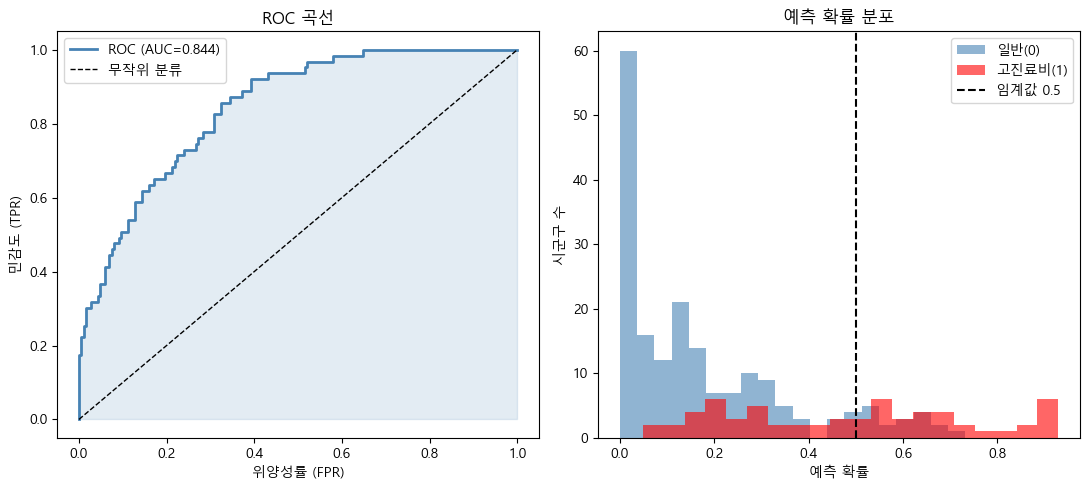

In [17]:
# 5. ROC 곡선 시각화
fpr, tpr, thresholds = roc_curve(
    Y, y_pred_prob)
fig, axes = plt.subplots(1, 2, figsize=(11,5))

# ROC 곡선
axes[0].plot(fpr, tpr, color='steelblue',
             lw=2, label=f'ROC (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',
             lw=1, label='무작위 분류')
axes[0].fill_between(fpr, tpr,
                     alpha=0.15, color='steelblue')
axes[0].set_xlabel('위양성률 (FPR)')
axes[0].set_ylabel('민감도 (TPR)')
axes[0].set_title('ROC 곡선')
axes[0].legend()

# 확률 분포
axes[1].hist(
    y_pred_prob[Y==0], bins=20,
    color='steelblue', alpha=0.6,
    label='일반(0)')
axes[1].hist(
    y_pred_prob[Y==1], bins=20,
    color='red', alpha=0.6,
    label='고진료비(1)')
axes[1].axvline(0.5, color='black',
                ls='--', lw=1.5, label='임계값 0.5')
axes[1].set_xlabel('예측 확률')
axes[1].set_ylabel('시군구 수')
axes[1].set_title('예측 확률 분포')
axes[1].legend()

plt.tight_layout()
plt.savefig('logistic_result.png', dpi=150)
plt.show()

## Model 03 — 로지스틱 회귀

### 종속변수 설정
- **임계값:** Q3 = 89.2만원 (75번째 백분위수)
- **고진료비(1):** 63개 시군구 (25.1%)
- **일반(0):** 188개 시군구 (74.9%)

---

### 1. 모델 적합도

| 지표 | 값 | 해석 |
|:---:|:---:|:---|
| Pseudo R² (McFadden) | **0.2944** | 0.2~0.4 = 우수한 모델 |
| LLR p-value | **3.52e-17** | 모델 전체 통계적으로 유의 |
| 수렴 여부 | **True** (8회 반복) | MLE 정상 수렴 |

---

### 2. 계수 & 오즈비

| 변수 | β | OR | 95% CI | p값 | 유의 | 해석 |
|:---|:---:|:---:|:---:|:---:|:---:|:---|
| 1인당_내원일수 | +0.5880 | **1.800** | [1.480, 2.191] | <0.001 | O | 1일↑ → 오즈 1.8배 |
| log_환자수 | +1.9421 | **6.973** | [3.770, 12.899] | <0.001 | O | 규모↑ → 오즈 7배 |
| 광역시 | +0.0559 | 1.058 | [0.464, 2.409] | 0.894 | X | 효과 없음 |
| 강원더미 | +1.5708 | 4.811 | [0.604, 38.302] | 0.138 | X | 미유의·CI 매우 넓음 |

> **강원더미 주의:** β 양수이나 p=0.138로 미유의.
> CI가 매우 넓어 추정 불안정.
> 내원일수·환자수 통제 후 억제 효과(Suppressor Effect)로
> 직관과 다른 부호가 나타날 수 있음.

> **Model 02와 일관된 발견:** 광역시·강원더미는 내원일수·환자수를
> 통제하면 진료비(연속) 및 고진료비 분류(이진) 모두에서 미유의.
> 지역 차이는 의료 이용량이 매개합니다.

---

### 3. 혼동행렬 (임계값 0.5)

|  | 예측: 일반(0) | 예측: 고진료비(1) |
|:---:|:---:|:---:|
| **실제: 일반(0)** | TN = 170 O | FP = 18 X |
| **실제: 고진료비(1)** | FN = 32 X | TP = 31 O |

| 지표 | 일반(0) | 고진료비(1) |
|:---:|:---:|:---:|
| 정밀도(Precision) | 84.2% | 63.3% |
| 재현율(Recall) | 90.4% | **49.2%** |
| F1-score | 87.2% | 55.4% |
| 정확도(Accuracy) | **80.1%** | — |

> **고진료비 재현율 49.2%:** 실제 고진료비 63개 중 32개를
> 일반으로 잘못 분류. 25:75 불균형 데이터에서 흔한 현상.
> 고진료비 탐지가 중요하다면 임계값을 0.5→0.3으로 낮추는 것을 고려.

---

### 4. 모델 성능

| 지표 | 값 | 해석 |
|:---:|:---:|:---|
| AUC | **0.844** | 우수 (0.8~0.9 구간) |
| 정확도 | **80.1%** | 251개 중 201개 정분류 |

> **ROC 곡선:** 좌상단으로 뚜렷하게 부풀어 무작위(0.5)보다
> 압도적으로 우수. 명확한 고진료비 시군구는 잘 탐지하나
> 경계선 시군구 분류는 어려움.

> **예측 확률 분포:** 일반(0)은 확률 0 근처 집중(정상),
> 고진료비(1)는 0~0.5 구간 분산 → 낮은 재현율의 원인.

---

### 5. 결론

- **유의한 변수:** 1인당_내원일수(OR=1.80), log_환자수(OR=6.97)
- **비유의 변수:** 광역시, 강원더미 (Model 02와 일관)
- **모델 성능:** AUC=0.844 — 우수, 정확도 80.1%
- **한계:** 고진료비 재현율 49.2% — 임계값 조정 또는 추가 변수 검토 필요

## 5. 모델 비교 종합 및 최종 예측

In [18]:
# 모델 비교 종합표

# 지표 집계
comparison = pd.DataFrame({
    '모델': ['M01 단순선형', 'M02 다중선형',
           'M03 로지스틱'],
    'Y 유형': ['연속형', '연속형', '이진형'],
    'X 개수': [1, 4, 4],
    'R² / AUC':[
        f"R² ={model.rsquared:.3f}",
        f"R² ={model2.rsquared:.3f}",
        f"AUC={0.8442:.3f}"],
    'AIC': [
        f"{model.aic:.1f}",
        f"{model2.aic:.1f}",
        f"-"],
    '유의 변수': [
        '내원일수',
        '내원일수, log_환자수',
        '내원일수, log_환자수'],
    '목적': ['탐색·기초', '설명력↑', '분류']
})
print("===== 모델 비교 종합 =====")
print(comparison.to_string(index=False))

===== 모델 비교 종합 =====
      모델 Y 유형  X 개수  R² / AUC   AIC         유의 변수    목적
M01 단순선형  연속형     1 R² =0.151 220.7          내원일수 탐색·기초
M02 다중선형  연속형     4 R² =0.648   5.6 내원일수, log_환자수  설명력↑
M03 로지스틱  이진형     4 AUC=0.844     - 내원일수, log_환자수    분류


### 5.1 실제값 vs 예측값 잔차 분석 (과소/과대 평가 지역)

In [20]:
# 예측값 생성
# Model 02로 예측값 + 원래 값 복원
X_pred = sm.add_constant(df[X_vars])
df['log_진료비_예측'] = model2.predict(X_pred)
df['진료비_예측_만원'] = (
    np.expm1(df['log_진료비_예측'])).round(1)
df['진료비_실제_만원'] = df['1인당_진료비_만원']
df['잔차'] = (
    df['진료비_실제_만원']
    - df['진료비_예측_만원']).round(1)

# 상위 5개 과소평가 시군구
print("\n===== 가장 많이 과소평가된 시군구 =====")
print("(실제 > 예측: 모델이 설명 못한 높은 진료비)")
under = df.nlargest(5, '잔차')[
    ['시도', '시군구', '진료비_실제_만원',
     '진료비_예측_만원', '잔차']]
print(under.to_string(index=False))

# 상위 5개 과대평가 시군구
print("\n===== 가장 많이 과대평가된 시군구 =====")
print("(예측 > 실제 : 모델이 높게 예측했지만 낮은 진료비)")
over = df.nsmallest(5, '잔차')[
    ['시도', '시군구', '진료비_실제_만원',
     '진료비_예측_만원', '잔차']]
print(over.to_string(index=False))


===== 가장 많이 과소평가된 시군구 =====
(실제 > 예측: 모델이 설명 못한 높은 진료비)
시도  시군구  진료비_실제_만원  진료비_예측_만원    잔차
전남  화순군      280.6       77.8 202.8
부산 부산서구      189.6       71.2 118.4
서울 서대문구      150.0       75.8  74.2
울산 울산동구      156.2       83.1  73.1
대구 대구남구      140.4       68.2  72.2

===== 가장 많이 과대평가된 시군구 =====
(예측 > 실제 : 모델이 높게 예측했지만 낮은 진료비)
시도   시군구  진료비_실제_만원  진료비_예측_만원    잔차
서울   마포구       37.6       69.9 -32.3
경기  남양주시       71.1      100.2 -29.1
대구 대구달성군       45.9       74.9 -29.0
경기   화성시       66.1       93.7 -27.6
대구 대구수성구       59.7       85.3 -25.6


### 5.2 가상 시나리오를 통한 시뮬레이션

In [23]:
# 가상 시나리오 예측
print("\n===== 가상 시나리오 예측 =====")
scenarios = pd.DataFrame({
    '시나리오':[
        '대도시 종합병원 거점',
        '중간 규모 도시',
        '소규모 농촌 지역',
        '강원도 산간 지역'],
    '1인당_내원일수': [12.0, 7.0, 5.0, 4.0],
    'log_환자수':     [14.5, 13.0, 11.0, 10.5],
    '광역시':         [1,    1,    0,    0],
    '강원더미':       [0,    0,    0,    1],
})
X_sc = sm.add_constant(
    scenarios[X_vars])
scenarios['예측_log'] = model2.predict(X_sc)
scenarios['예측_진료비_만원'] = (
    np.expm1(scenarios['예측_log'])).round(1)

logit_X = sm.add_constant(
    scenarios[X_vars])
scenarios['고진료비_확률'] = (
    logit_model.predict(logit_X) * 100
).round(1)

print(scenarios[['시나리오',
                 '예측_진료비_만원',
                 '고진료비_확률']].to_string(index=False))


===== 가상 시나리오 예측 =====
       시나리오  예측_진료비_만원  고진료비_확률
대도시 종합병원 거점      123.8     91.1
   중간 규모 도시       55.5      2.9
  소규모 농촌 지역       26.8      0.0
  강원도 산간 지역       21.1      0.0


In [25]:
# 변수 중요도 통합 정리
importance = pd.DataFrame({
    '변수': ['1인당_내원일수', 'log_환자수',
           '광역시', '강원더미'],
    'M02_β*': [0.2566, 0.2841, 0.0305, -0.0067],
    'M03_OR': [1.800, 6.973, 1.058, 4.811],
    'M02_유의': ['O','O','X','X'],
    'M03_유의': ['O','O','X','X'],
})
print("\n===== 변수 중요도 통합 =====")
print(importance.to_string(index=False))


===== 변수 중요도 통합 =====
      변수  M02_β*  M03_OR M02_유의 M03_유의
1인당_내원일수  0.2566   1.800      O      O
 log_환자수  0.2841   6.973      O      O
     광역시  0.0305   1.058      X      X
    강원더미 -0.0067   4.811      X      X


In [26]:
importance

,변수,M02_β*,M03_OR,M02_유의,M03_유의
0,1인당_내원일수,0.2566,1.800,O,O
1,log_환자수,0.2841,6.973,O,O
2,광역시,0.0305,1.058,X,X
3,강원더미,-0.0067,4.811,X,X


## 6. 최종 결론 및 인사이트 요약

## Model 04 — 모델 비교 & 최종 해석

### 1. 모델 비교 종합

| 구분 | Model 01 | Model 02 | Model 03 |
|:---:|:---:|:---:|:---:|
| 종류 | 단순 선형회귀 | 다중 선형회귀 | 로지스틱 회귀 |
| 종속변수 | log(진료비) | log(진료비) | 고진료비(0/1) |
| 독립변수 수 | 1개 | 4개 | 4개 |
| R² / AUC | R²=0.151 | R²=0.648 | AUC=0.844 |
| AIC | 220.7 | **5.6** | — |
| 목적 | 탐색·기초 | 설명력 최대화 | 분류·예측 |
| 선택 | X | O 진료비 예측 | O 고진료비 분류 |

> **모델 선택 기준:** ΔAIC = 220.7 - 5.6 = **215.1 (≫10)**
> → Model 02가 Model 01보다 압도적으로 우수.
> Model 02(연속 예측)와 Model 03(분류)은 목적이 달라 경쟁 아닌 보완.

---

### 2. 변수 중요도 통합 (M02·M03 공통)

| 순위 | 변수 | M02 β* | M03 OR | 양 모델 유의 |
|:---:|:---|:---:|:---:|:---:|
| 1 | log_환자수 | 0.284 | 6.97 | O O |
| 2 | 1인당_내원일수 | 0.257 | 1.80 | O O |
| 3 | 광역시 | 0.031 | 1.06 | X X |
| 4 | 강원더미 | -0.007 | 4.81 | X X |

> 두 모델 모두 내원일수·환자수만 유의. 지역 더미는 미유의.

---

### 3. 핵심 인사이트 3가지

1. **환자 규모가 진료비의 1순위 결정 변수**
   - log_환자수: M02 β*=0.284 (1위), M03 OR=6.97
   - 광역시이기 때문이 아닌, 많은 환자가 모이기 때문

2. **내원일수 = 중증도 간접 지표**
   - M01: 5.6%/일 → M02: 9.3%/일 (환자수 통제 후 순수 효과)
   - 거점병원 지역(화순군·익산시)에서 두드러짐

3. **지역 효과는 이용량이 매개 — 정책적 함의**
   - 지역 더미 미유의 = 지역 격차의 원인은 지역 자체가 아닌
     의료 이용량(접근성) 차이
   - 강원도 지원보다 의료기관 접근성 개선이 효과적

---

### 4. 예측값 활용

#### 과소평가 TOP 5 (실제 > 예측 — 모델이 설명 못한 높은 진료비)
| 시도 | 시군구 | 실제(만원) | 예측(만원) | 잔차 |
|:---:|:---:|:---:|:---:|:---:|
| 전남 | 화순군 | 280.6 | 77.8 | +202.8 |
| 부산 | 부산서구 | 189.6 | 71.2 | +118.4 |
| 울산 | 울산동구 | 156.2 | 83.1 | +73.1 |
| 서울 | 서대문구 | 150.0 | 75.8 | +74.2 |
| 대구 | 대구남구 | 140.4 | 68.2 | +72.2 |

> 공통점: 모두 지역 거점 대학병원·종합병원 소재지.
> 병원 종별·전문의 수 변수 추가 시 설명력 개선 기대.

#### 과대평가 TOP 5 (예측 > 실제 — 모델이 높게 예측했지만 실제는 낮음)
| 시도 | 시군구 | 실제(만원) | 예측(만원) | 잔차 |
|:---:|:---:|:---:|:---:|:---:|
| 서울 | 마포구 | 37.6 | 69.9 | -32.3 |
| 경기 | 남양주시 | 71.1 | 100.2 | -29.1 |
| 대구 | 달성군 | 45.9 | 74.9 | -29.0 |
| 경기 | 화성시 | 66.1 | 93.7 | -27.6 |
| 대구 | 수성구 | 59.7 | 85.3 | -25.6 |

> 공통점: 환자수·규모는 크지만 진료비가 낮음.
> 베드타운·신도시 성격 — 경증 외래 이용 위주, 중증 환자는 인근
> 대도시로 이동하는 패턴 반영.

#### 가상 시나리오 예측

| 시나리오 | 예측 진료비 | 고진료비 확률 |
|:---|:---:|:---:|
| 대도시 종합병원 거점 (내원 12일, 환자 多) | **123.8만원** | **91.1%** |
| 중간 규모 도시 (내원 7일, 환자 보통) | **55.5만원** | **2.9%** |
| 소규모 농촌 (내원 5일, 환자 少) | **26.8만원** | **0.0%** |
| 강원도 산간 (내원 4일, 환자 極少) | **21.1만원** | **0.0%** |

---

### 5. 전체 분석 흐름 요약

```
1단계 전처리  → 251개 시군구, 8개 변수, 결측치 0개
2단계 EDA     → 화순군 이상치, 시도별 격차, 왜도 1.619
3단계 검정    → 정규성 기각 → 비모수 검정 채택
               강원도만 유의 이탈 (Dunn 사후검정)
               환자수·내원일수 ↔ 진료비 상관 (Spearman)
4단계 모델링  → M02: R²=0.648 (유의: 내원일수·환자수)
               M03: AUC=0.844 (유의: 내원일수·환자수)
결론          → 지역이 아닌 의료 이용량이 진료비를 결정
```